# Chapter 5: Pretraining our model

It is first required of us to import previously created classes and define model hyper_params. Only change in hyper params, is the reduction in size of context length from 1024 to 256, required for training our dataset without the necessity of heavy GPUs.

In [6]:
import torch
import tiktoken
import GPT_Classes

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123) # for reproducability of work

model = GPT_Classes.GPTModel(GPT_CONFIG_124M) # creating instance of model
model.eval() # disabling dropout for inference

GPTModel(
  (token_emb): Embedding(50257, 768)
  (positional_emb): Embedding(256, 768)
  (dropper): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attention_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (Dropper): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (op_pipeline): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): 

## 5.1: Generating simple text from data and using loss function as a measure of model accuracy

Two convenience functions are first defined

In [15]:
def text_to_tokens(text, tokeniser: tiktoken.Encoding):
    tokens = tokeniser.encode(text, allowed_special={"|<endoftext>|"})
    return torch.tensor(tokens).unsqueeze(0)

def tokens_to_text(tokens : torch.Tensor, tokeniser: tiktoken.Encoding):
    return tokeniser.decode(tokens.squeeze(0).tolist())

tokeniser=tiktoken.get_encoding("gpt2")
sample = "Every effort moves you"

tokens = text_to_tokens(sample, tokeniser)
print(tokens)
print(tokens_to_text(tokens, tokeniser))

print(tokens_to_text(GPT_Classes.text_generater(model, tokens, GPT_CONFIG_124M["context_length"], 10), tokeniser))

tensor([[6109, 3626, 6100,  345]])
Every effort moves you
Every effort moves you rentingetic wasnم refres RexMeCHicular stren


Now that we have a basic setup for text generation, we dive into loss functions

In [61]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

# We shall see the loss functions for this test data first.

logits = model(inputs)
print(logits.shape)

torch.Size([2, 3, 50257])


In [62]:
probs = torch.softmax(logits, -1)
print(probs.shape)
output_tokens = torch.argmax(probs, -1, keepdim=True)
print(output_tokens[0].squeeze(-1))
print(tokens_to_text(output_tokens[0].squeeze(-1), tokeniser))

torch.Size([2, 3, 50257])
tensor([16657,   339, 42826])
 Armed heNetflix


In [63]:
# To get probabilities of expected tokens
target_probs_1 = probs[0, [0,1,2], targets[0]]
target_probs_2 = probs[1, [0,1,2], targets[1]]

target_probs_1_log = torch.log(target_probs_1)
target_probs_2_log = torch.log(target_probs_2)
log_probs = torch.cat([target_probs_1_log, target_probs_2_log])
print(log_probs)
avg_log_probs = torch.mean(log_probs)
print(avg_log_probs)
print(logits.shape, targets.shape)


tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561],
       grad_fn=<CatBackward0>)
tensor(-10.7940, grad_fn=<MeanBackward0>)
torch.Size([2, 3, 50257]) torch.Size([2, 3])


This is our loss function, average negative probabilities of the expected tokens. This can be computed efficiently by pytorch's cross ecntropy loss functions. The dimensions of the input tensors need to be taken care of in the following way

In [64]:
loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), targets.flatten())
print(loss)

tensor(10.7940, grad_fn=<NllLossBackward0>)


Now we shall prep our model to train on verdict.txt

In [65]:
with open("verdict.txt", 'r') as file:
    text = file.read()

total_char = len(text)
total_tokens = len(tokeniser.encode(text, allowed_special={"|<endoftext>|"}))
print(total_char, total_tokens)

20479 5145


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/batching.webp" width=500px>

This figure outlays our next plans

In [66]:
training_ratio = 0.9
test_token_number = int(training_ratio*len(text))

training_tokens = text[:test_token_number]
validating_tokens = text[test_token_number:]

training_dataset = GPT_Classes.create_dataloader_v1(training_tokens, 2, GPT_CONFIG_124M["context_length"], GPT_CONFIG_124M["context_length"], True, True)
validating_dataset = GPT_Classes.create_dataloader_v1(validating_tokens, 2, GPT_CONFIG_124M["context_length"], GPT_CONFIG_124M["context_length"], False, False)

for x,y in training_dataset:
    print(x.shape, y.shape)


torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


Next up, a basic loss calculation framework is implented

In [67]:
device = torch.device("cuda")

def calc_loss(inputs : torch.Tensor, expected_outputs, model):
    inputs, expected_outputs = inputs.to(device), expected_outputs.to(device)
    logits = model(inputs)
    return torch.nn.functional.cross_entropy(logits.flatten(0,1), expected_outputs.flatten(0))

def calc_loss_loader(dataloader, model, num_batches = None):
    total_loss = 0
    if len(dataloader)==0:
        return total_loss
    elif num_batches==None:
        num_batches = len(dataloader)
    else:
        num_batches = min(len(dataloader), num_batches)
    for i, (inputs, targets) in enumerate(dataloader):
        if i<num_batches:
            total_loss+=calc_loss(inputs, targets, model).item()
        else:
            break

    return total_loss/num_batches

model.to(device)
with torch.no_grad():
    print(calc_loss_loader(training_dataset, model))
    print(calc_loss_loader(validating_dataset, model))

10.987583372328016
10.981104850769043


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model-1.webp" width=400px>

## 5.2: It is now time to train our model using backpropagation

In [68]:
def training_function(model, dataloader_training, validating_dataset, num_epochs, optimiser : torch.optim.AdamW, device, eval_iter ):
    model.to(device)
    tokens_seen = 0
    val_freq = 5
    global_step = 0
    train_losses, val_losses, track_tokens_seen = [],[],[]
    for i in range(num_epochs):
        model.train()
        for inputs, targets in dataloader_training:
            optimiser.zero_grad() #clear out previous gradients
            loss = calc_loss(inputs, targets, model)
            loss.backward()
            optimiser.step()
            tokens_seen += inputs.numel()
            global_step += 1

            if global_step%val_freq==0:
                train_loss, valid_loss = evaluate_model(model, dataloader_training, validating_dataset, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(valid_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Epoch: {i} Step: {global_step} Training loss: {train_loss} Validation Loss: {valid_loss} ")
        model.eval()
        print(tokens_to_text(GPT_Classes.text_generater(model, text_to_tokens(sample, tokeniser).to(device), 256, 50), tokeniser).replace('\n', " "))
    return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, eval_iter)
        val_loss = calc_loss_loader(val_loader, model, eval_iter)
    model.train()
    return train_loss, val_loss



In [94]:
del model
torch.manual_seed(123)

model = GPT_Classes.GPTModel(GPT_CONFIG_124M)
model.to(device)

optimiser = torch.optim.AdamW(model.parameters(), lr = 0.0004, weight_decay=0.1)
train_losses, val_losses, tokens_seen_tracker = training_function(model, training_dataset, validating_dataset, 10, optimiser, device, eval_iter=5 )

Epoch: 0 Step: 5 Training loss: 8.55921802520752 Validation Loss: 8.635708808898926 
Every effort moves you,,,,,,,,,,,,,,.                                   
Epoch: 1 Step: 10 Training loss: 6.979195022583008 Validation Loss: 7.235165119171143 
Epoch: 1 Step: 15 Training loss: 6.105388927459717 Validation Loss: 6.644505977630615 
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and,, and, and,
Epoch: 2 Step: 20 Training loss: 5.7574444770812985 Validation Loss: 6.488873481750488 
Epoch: 2 Step: 25 Training loss: 5.623210811614991 Validation Loss: 6.487251281738281 
Every effort moves you, and to the!! of the! to the to the to the a, and I had to the to to to the to the of the to the of the St, and, and, and, and, and, and, and,
Epoch: 3 Step: 30 Training loss: 5.3413091659545895 Validation Loss: 6.466639041900635 
Epoch: 3 Step: 35 Training loss: 5.128315734863281 Validation Loss: 6.403794765472412 
Every e

In [95]:
print(torch.cuda.is_available())
print(tokens_seen_tracker)

True
[2560, 5120, 7680, 10240, 12800, 15360, 17920, 20480, 23040, 25600, 28160, 30720, 33280, 35840, 38400, 40960, 43520, 46080]


Now, that we can train our model, we implement a function to visual the model's training progress

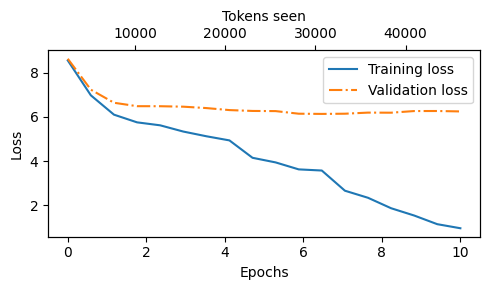

In [96]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

#train_losses = [x.item() for x in train_losses]
#val_losses = [x.item() for x in val_losses]
epochs_tensor = torch.linspace(0, 10, len(train_losses)).to("cpu")
plot_losses(epochs_tensor, tokens_seen_tracker, train_losses, val_losses)

We see that, the loss keeps going down for training, but stagnates for validation. This is becuase our training dataset is extremely limit which does not allow the model to generalize for all texts. But since we are limited by the computational resources, we will use the model weights of pretrained gpt-2

## 5.3: Fighting overfitting with generalising strategies

### 5.3.1: Temperature Scaling

Below is the basic mechanism for finding next token

In [97]:
vocab = {  ## sample vocab
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# assume these are the logits obtained for next word
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0) # normalisation
next_token_id = torch.argmax(probas).item() # finding highest prob token

# matching the id of the token obtained
print(inverse_vocab[next_token_id])

forward


instead of just finding next token with highest probability, we can sample the probability distribution, to get the next token acc to its proobability

In [98]:
next_token = torch.multinomial(probas, 1)
print(inverse_vocab[next_token.item()])

forward


Now what scaling does is that it divides all logits by a temperature T. If T>1, the sampling distribution becomes less sharp. If T<1, the sampling distribution becomes sharper

In [99]:
Temperatures = [0.1, 1, 1.2]
scaled_logits = [next_token_logits/Temperatures[i] for i in range(len(Temperatures))]

probs = [torch.softmax(scaled_logits[i], -1) for i in range(3)]
print(probs)
def print_sampled_tokens(probas): #function for finding frequency of each token in the sampled data
    ans = []
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
        ans.append(freq.item())
    return ans

freqs = [print_sampled_tokens(probs[i]) for i in range(3)]
print(freqs)


[tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22]), tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03]), tensor([8.2667e-02, 4.0477e-03, 3.9580e-04, 5.3458e-01, 7.4994e-03, 4.9982e-04,
        3.9911e-04, 3.6134e-01, 8.5690e-03])]
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you
96 x closer
2 x every
0 x effort
536 x forward
4 x inches
0 x moves
0 x pizza
355 x toward
7 x you
[[0, 0, 0, 985, 0, 0, 0, 15, 0], [73, 0, 0, 582, 2, 0, 0, 343, 0], [96, 2, 0, 536, 4, 0, 0, 355, 7]]


To view this as a graph,

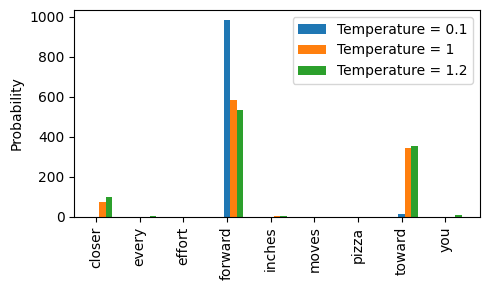

In [100]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(Temperatures):
    rects = ax.bar(x + i * bar_width, freqs[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

### 5.3.2: K-sampling

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/topk.webp" width=500px>

- (Please note that the numbers in this figure are truncated to two
digits after the decimal point to reduce visual clutter. The values in the Softmax row should add up to 1.0.)

In [76]:
k_probas, k_indices = torch.topk(next_token_logits, k=3)
print(k_probas)
print(k_indices)

tensor([6.7500, 6.2800, 4.5100])
tensor([3, 7, 0])


In [77]:
next_token_logits = torch.where(next_token_logits < k_probas[-1], torch.tensor(-torch.inf), next_token_logits)
print(next_token_logits)

topk_probs = torch.softmax(next_token_logits, -1)
print(topk_probs)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### 5.3.3: Modifying text_generator to incorporate abouve two strategies 

In [13]:
def better_text_generator(model, token_data, context_size, max_new_tokens, temperature, eos_id = None, k = None):
    for _ in range(max_new_tokens):
        context = token_data[:, -context_size:]
        with torch.no_grad():
            logits = model(context)
        new_token_logits = logits[:,-1,:]

        if k:
            new_token_logits = torch.where(new_token_logits < torch.topk(new_token_logits, k)[0][:,-1], torch.tensor(-torch.inf), new_token_logits)
        
        if temperature:
            new_token_logits = new_token_logits/temperature
            probs = torch.softmax(new_token_logits, -1)
            new_token = torch.multinomial(probs, 1)
        else:
            probs = torch.softmax(new_token_logits, -1)
            new_token = torch.argmax(probs, -1)
        
        if new_token == eos_id:
            break
        print(new_token)
        token_data = torch.cat((token_data, new_token), -1)
    return token_data


Let's Check

In [102]:
torch.manual_seed(123)
model.to("cpu")

token_ids = better_text_generator(model, text_to_tokens("Every effort moves you", tokeniser), GPT_CONFIG_124M["context_length"],
                                  20, 1.4, k=25)
print(token_ids)
print("Output text:\n", tokens_to_text(token_ids, tokeniser))

tensor([[18250]])
tensor([[553]])
tensor([[373]])
tensor([[866]])
tensor([[5975]])
tensor([[13]])
tensor([[632]])
tensor([[318]])
tensor([[284]])
tensor([[423]])
tensor([[326]])
tensor([[1785]])
tensor([[416]])
tensor([[465]])
tensor([[14475]])
tensor([[13]])
tensor([[18612]])
tensor([[338]])
tensor([[262]])
tensor([[582]])
tensor([[ 6109,  3626,  6100,   345, 18250,   553,   373,   866,  5975,    13,
           632,   318,   284,   423,   326,  1785,   416,   465, 14475,    13,
         18612,   338,   262,   582]])
Output text:
 Every effort moves youlit," was down surprise. It is to have that event by his knees. Professional's the man


## 5.4: Saving trained weights

In [ ]:
torch.save(model.state_dict(), "model_weight.pth") # model weights stored in model_weight.pth

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model = GPT_Classes.GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model_weight.pth", map_location=device, weights_only=True))
model.eval() #inference mode

GPTModel(
  (token_emb): Embedding(50257, 768)
  (positional_emb): Embedding(256, 768)
  (dropper): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attention_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (Dropper): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (op_pipeline): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): 

## 5.5: Loading pre-trained weights from GPT-2

In [4]:
import tensorflow, tqdm
from gpt_download import download_and_load_gpt2
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json


model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [01:59<00:00, 4.15MiB/s]   


File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


Settings contains hyperparameters for our model, and params contains all the weights

We have chosen the 124M sized model. All the models have the same principles just varying sizes as explained in the figure below

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/gpt-sizes.webp?timestamp=123" width=500px>

We have the weights, now we need to copy them into an instance of our GPTModel

In [7]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name]) # setting hyperparams acc to model size
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPT_Classes.GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (token_emb): Embedding(50257, 768)
  (positional_emb): Embedding(1024, 768)
  (dropper): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attention_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (Dropper): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (op_pipeline): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): La

Below, is the code for appropriately copying pre trained weights, according to the structure of the params dictionary made by OpenAI

In [11]:
import numpy as np

def assign(left, right):
    if left.shape != right.shape:
        raise ValueError("Shapes no equal")
    return torch.nn.Parameter(torch.tensor(right))
    
def load_weights_into_gpt(gpt, params):
    gpt.positional_emb.weight = assign(gpt.positional_emb.weight, params['wpe'])
    gpt.token_emb.weight = assign(gpt.token_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.transformer_blocks[b].attention_block.W_query.weight = assign(
            gpt.transformer_blocks[b].attention_block.W_query.weight, q_w.T)
        gpt.transformer_blocks[b].attention_block.W_key.weight = assign(
            gpt.transformer_blocks[b].attention_block.W_key.weight, k_w.T)
        gpt.transformer_blocks[b].attention_block.W_value.weight = assign(
            gpt.transformer_blocks[b].attention_block.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.transformer_blocks[b].attention_block.W_query.bias = assign(
            gpt.transformer_blocks[b].attention_block.W_query.bias, q_b)
        gpt.transformer_blocks[b].attention_block.W_key.bias = assign(
            gpt.transformer_blocks[b].attention_block.W_key.bias, k_b)
        gpt.transformer_blocks[b].attention_block.W_value.bias = assign(
            gpt.transformer_blocks[b].attention_block.W_value.bias, v_b)

        gpt.transformer_blocks[b].attention_block.out_proj.weight = assign(
            gpt.transformer_blocks[b].attention_block.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].attention_block.out_proj.bias = assign(
            gpt.transformer_blocks[b].attention_block.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.transformer_blocks[b].ffn.op_pipeline[0].weight = assign(
            gpt.transformer_blocks[b].ffn.op_pipeline[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer_blocks[b].ffn.op_pipeline[0].bias = assign(
            gpt.transformer_blocks[b].ffn.op_pipeline[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer_blocks[b].ffn.op_pipeline[2].weight = assign(
            gpt.transformer_blocks[b].ffn.op_pipeline[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].ffn.op_pipeline[2].bias = assign(
            gpt.transformer_blocks[b].ffn.op_pipeline[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.transformer_blocks[b].norm1.scale = assign(
            gpt.transformer_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.transformer_blocks[b].norm1.shift = assign(
            gpt.transformer_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.transformer_blocks[b].norm2.scale = assign(
            gpt.transformer_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.transformer_blocks[b].norm2.shift = assign(
            gpt.transformer_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_layer.weight = assign(gpt.out_layer.weight, params["wte"])
    
load_weights_into_gpt(gpt, params)
gpt.to("cpu")

GPTModel(
  (token_emb): Embedding(50257, 768)
  (positional_emb): Embedding(1024, 768)
  (dropper): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attention_block): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (Dropper): Dropout(p=0.1, inplace=False)
      (ffn): FeedForward(
        (op_pipeline): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): La

Now time to test it

In [17]:
torch.manual_seed(123)

tokens = better_text_generator(gpt, text_to_tokens("Every effort takes you", tokeniser), NEW_CONFIG["context_length"], 100, 1.5, k=50)
print(tokens_to_text(tokens, tokeniser))

tensor([[281]])
tensor([[8131]])
tensor([[890]])
tensor([[640]])
tensor([[13]])
tensor([[2080]])
tensor([[257]])
tensor([[1310]])
tensor([[3357]])
tensor([[345]])
tensor([[460]])
tensor([[923]])
tensor([[534]])
tensor([[1110]])
tensor([[416]])
tensor([[28175]])
tensor([[290]])
tensor([[1972]])
tensor([[319]])
tensor([[351]])
tensor([[644]])
tensor([[5300]])
tensor([[749]])
tensor([[3288]])
tensor([[1399]])
tensor([[383]])
tensor([[1266]])
tensor([[1517]])
tensor([[546]])
tensor([[428]])
tensor([[5496]])
tensor([[318]])
tensor([[326]])
tensor([[2506]])
tensor([[481]])
tensor([[2883]])
tensor([[340]])
tensor([[290]])
tensor([[326]])
tensor([[257]])
tensor([[1487]])
tensor([[379]])
tensor([[262]])
tensor([[7480]])
tensor([[561]])
tensor([[1249]])
tensor([[2506]])
tensor([[284]])
tensor([[1011]])
tensor([[511]])
tensor([[640]])
tensor([[290]])
tensor([[307]])
tensor([[4988]])
tensor([[5763]])
tensor([[876]])
tensor([[286]])
tensor([[326]])
tensor([[543]])
tensor([[484]])
tensor([[821]])
te

Since generated text is coherent, the weight were copied correctly